# Logistic Regression

Logistic regression is used in **Classification** problems, where there is only 2 possible outputs to predict. 

Classic examples of real-life problems where this is applied include:
- Fraud detection (*fraud* or *not fraud*)
- Spam email detection (*spam* or *not spam*)
- Tumour assessment (*benign* or *malignant*)
 
Whereas *Linear* Regression generates an output $\hat{y}$ from an infinite possible range of numbers, logistic regression constrains **$\hat{y}$** to lie between 0 and 1.

In this case, $\hat{y}$ represents the probability that the input example falls into a particular class. 

----

The foundations of a logistic regression function start from a linear regression model: 
$$
f_{w,b}(x^{(i)}) = w \cdot x^{(i)} + b
$$

However, we need some way of constraining values of $f_{w,b}(x^{(i)})$ to lie between 0 and 1. 

The solution is to apply the **sigmoid function**, which maps $f_{w,b}(x^{(i)})$ to a value between 0 and 1. 

This function takes the form:
$$
g(z) = \frac{1}{1+e^{-z}}
$$
and looks like:

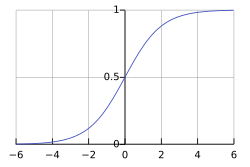

In other words, our logistic regression function is:

$$ 
f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b )
$$

---

Step 1: Let's **define** this sigmoid function

In [8]:
def sigmoid(z):
    """
    Args: 
    z (ndarray): This is our input "w . x(i) + b", which will be an array of any size depending on our training set; m examples and n features

    Returns:
    g (ndarray): Sigmoid function with the same shape as z; m examples and n features
    """

    g = 1 / (1 + np.exp(-z))

    return g

As you may recall from our linear regression models, our next step was to compute a Cost Function. 

We defined this previously as:
$$
J(w, b) = \frac{1}{2m} \sum_{i=0}^{m-1} \left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2
$$

where it took a sum of the individual *"loss"* (i.e. discrepancy between prediction and actual values) for each example in the dataset. In this case, our loss function was **Mean Squared Error**

$$
\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2
$$

For logistic regression, our *loss* function for each example looks slightly different

$$
loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)
$$

Our cost function is then a sum of the loss for all examples.

$$ J(\mathbf{w},b) = \frac{1}{m} \sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

---

Step 2: Let's **compute** this cost function

In [9]:
def compute_cost(X,y,w,b):
    """
    Arguments:
    X (ndarray): dataset with shape (m,n); m examples and n features
    y (1d-array): array of output values with shape (m, ); m values
    w (ndarray): array of weights with shape (n, ); n weights
    b (scalar): bias with shape (); 1 value

    Returns:
    J (float): Cost from using parameters (w,b) to predict y using X
    """

    m,n = X.shape
    J = 0.0

    for i in range(m):
        fwb_i = sigmoid(np.dot(w, X[i]) + b)
        loss = (-y[i] * np.log(fwb_i)) - ((1-y[i]) * np.log(1-fwb_i))
        J += loss
    J = J / m

    return J

Next, similar to our approach for linear regression, we will implement gradient descent to optimise our parameters $(w,b)$

Recall that we update $w$ and $b$ according to:

$$
w \leftarrow w - \alpha \cdot \frac{\partial J(w, b)}{\partial w}
$$

$$
b \leftarrow b - \alpha \cdot \frac{\partial J(w, b)}{\partial b}
$$

Our first step is to compute the gradients $\frac{\partial J(w, b)}{\partial w}$ and $\frac{\partial J(w, b)}{\partial b}$ where:

$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)}) \tag{2}
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)} \tag{3}
$$

---

Step 3: **Compute** gradients

In [10]:
def compute_gradient(X,y,w,b):
    """
    Arguments:
    X (ndarray): dataset with shape (m,n); m examples and n features
    y (1d-array): array of output with shape (m, ); m values
    w (ndarray): array of weights with shape (n, ); n weights
    b (scalar): bias with shape (); 1 value

    Returns:
    dj_dw (1d-array): array of gradients w.r.t to each weight, with shape (n, ); n gradients
    dj_db (scalar): gradient w.r.t to bias with shape (); 1 value
    """

    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0

    for i in range(m):
        z_i = np.dot(w, X[i]) + b
        fwb_i = sigmoid(z_i)
        error = fwb_i - y[i]
        dj_db += error
        for j in range(n):
            dj_dw[j] += error * X[i,j]

    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw, dj_db

Though the structure of the function above may seem identical to that of linear regression, note that we have applied the sigmoid function to `np.dot(w, X[i]) + b`. 

Resultingly, $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is defined differently.

---

Given gradients, $\frac{\partial J(w, b)}{\partial w}$ and $\frac{\partial J(w, b)}{\partial b}$, we can now run gradient descent.

---

Step 4: **Run** gradient descent

*(Note that this code is **identical** to linear regression)*

In [11]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    """
    Args:
    X (ndarray): dataset with shape (m,n); m examples, n features
    y (1d-array): array of output values with shape (m, ); m values
    w_in (ndarray): array of initial weights with shape (n, ); n weights
    b_in (scalar): inital bias with shape (); 1 value
    cost_function: function to compute cost ~ see compute_cost() above
    gradient_function: function to compute gradient ~ see compute_gradient() above
    alpha (float): learning rate for gradient descent
    num_iters (int): number of iterations to run gradient descent

    Returns:
    w (ndarray): final values of parameter w
    b (scalar): final value of parameter b
    """
    w = w_in
    b = b_in
    m,n = x.shape
    cost_history = {}
    
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x,y,w,b)
        for j in range(n):
            w[j] -= alpha * dj_dw[j]
        b -= alpha * dj_db

        # print cost at every interval 10-times or every iteration if < 10
        if i% math.ceil(num_iters / 10) == 0: #
            J = compute_cost(x,y,w,b)
            cost_history[i] = J
            print(f"Iteration {i:4d}: Cost {cost_history[-1]:8.2f}   ")

    return w, b, cost_history

**Finally**, we can convert the probability outputs of our logistic regression model into **predictions** of the class labels for our dataset examples. 

Since logistic regression model outputs **a probability between 0 and 1**, we need to define a **decision boundary** to convert those probabilities into class predictions. 

A decision boundary is a threshold such that that:
$$
\hat{y}^{(i)} = 
\begin{cases}
1 & \text{if } f_{\mathbf{w},b}(\mathbf{x}^{(i)}) \geq \text{decision boundary} \\
0 & \text{if } f_{\mathbf{w},b}(\mathbf{x}^{(i)}) < \text{decision boundary}
\end{cases}
$$


By default, the decision boundary is set to 0.5, meaning that we classify the example as class 1 if the model's predicted probability exceeds 0.5

---

Step 5: **Classify** prediction function

In [12]:
def predict(X,w,b, decision_boundary):
    """
    Arguments:
    X (ndarray): dataset with shape (m,n); m examples, n features
    w (ndarray): weights with shape (n, ); n weights
    b (scalar): bias with shape (); 1 value
    decision_boundary (float): threshold to convert probabilities into class predictions; 1 value

    Returns:
    p (ndarray): predicted class labels (0 or 1) for each example with shape (m, ); m predictions
    """
    m,n = X.shape
    p = np.zeros(m)

    for i in range(m):
        z_i = np.dot(w, X[i]) + b
        fwb_i = sigmoid(z_i)

        if fwb_i >= decision_boundary:
            p[i] = 1
        else:
            p[i] = 0

    return p